# Engine Health State Classification

In the previous regression task, the goal was to predict the **Remaining Useful Life (RUL)** of a turbofan engine from its sensor measurements.

In this notebook, we convert the problem into a **multi-class classification task**. Instead of predicting an exact RUL value, the model predicts the current **health severity** of the engine.

```text
Sensor Measurements → Health State
```

The engine condition is divided into three states:

| Health State    | Description                                                                |
| --------------- | -------------------------------------------------------------------------- |
| 🟢 **Healthy**  | The engine is operating far from failure.                                  |
| 🟡 **Warning**  | The engine shows significant degradation and requires increased attention. |
| 🔴 **Critical** | The engine is approaching failure and requires immediate attention.        |

These classes will be derived from the engine's RUL using predefined thresholds.

### Objective

The main objective is to develop an **Early Warning System** that can identify the severity of engine degradation from sensor measurements.

Because this is a predictive maintenance problem, the evaluation will focus not only on overall accuracy but also on the model's ability to correctly identify **Warning** and especially **Critical** conditions.



## Imports and Configuration

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

c:\Users\hosse\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


## Load Prepared Data

In [3]:
file_names = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'train_engine_ids']

for name in file_names:
    globals()[name] = pd.read_csv(f'data/processed/{name}.csv')

In [4]:
X_train.shape, train_engine_ids.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((16561, 16),
 (16561, 1),
 (16561, 1),
 (4070, 16),
 (4070, 1),
 (100, 16),
 (100, 1))

In [5]:
y_train = y_train.squeeze()
y_val = y_val.squeeze()
y_test = y_test.squeeze()
train_engine_ids = train_engine_ids.squeeze()

## Define Health States

In [ ]:
HEALTHY_MAX_RUL = 100   # RUL > 100  -> Healthy  (boundary kept below the NB01 RUL cap of 125)
WARNING_MAX_RUL = 30    # 30 < RUL <= 100 -> Warning; RUL <= 30 -> Critical (~30-cycle maintenance lead time)
Critical = 2

def map_to_class(rul):
    if rul > HEALTHY_MAX_RUL:
        return 0
    if rul > WARNING_MAX_RUL:
        return 1
    return 2

In [7]:
y_train = y_train.apply(map_to_class)
y_val = y_val.apply(map_to_class)
y_test = y_test.apply(map_to_class)

### Class Distribution Analysis


Text(0.5, 1.0, 'train distribiution')

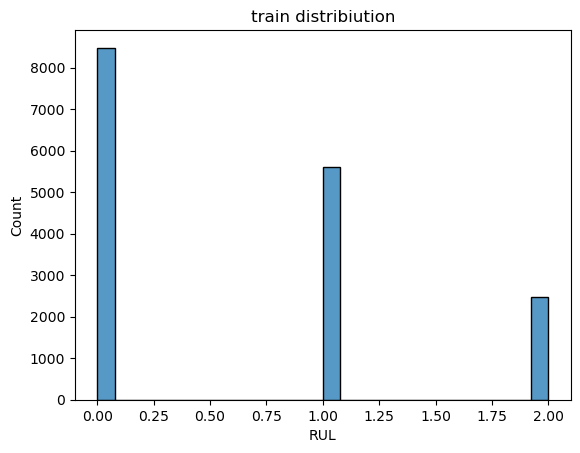

In [8]:
sns.histplot(y_train)
plt.title("train distribiution")

Text(0.5, 1.0, 'validation distribiution')

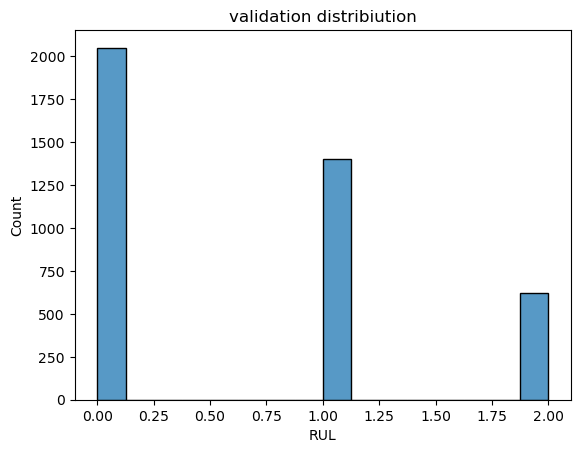

In [9]:
sns.histplot(y_val)
plt.title("validation distribiution")

The distribution plot reveals an asymmetrical pattern skewed toward healthier engines. To handle this class imbalance, we will apply techniques such as class weighting in the classification models.

Text(0.5, 1.0, 'test distribiution')

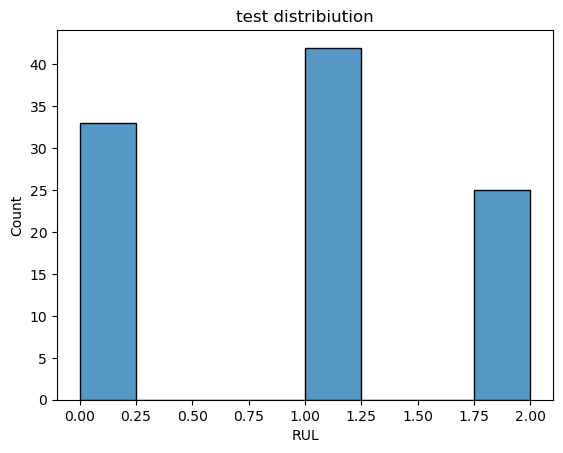

In [10]:
sns.histplot(y_test)
plt.title("test distribiution")


## Evaluation Metrics

We evaluate classification performance using **Accuracy, Balanced Accuracy, Macro F1, Critical Precision, and Critical Recall**.

* **Accuracy**: The proportion of all predictions that are correctly classified. Higher values indicate better overall performance.

* **Balanced Accuracy**: The average recall across all classes. It is particularly useful when the dataset is imbalanced because each class contributes equally to the final score.

* **Macro F1**: The average F1-score across all classes, giving equal importance to Healthy, Warning, and Critical states. Higher values indicate more balanced performance across classes.

* **Critical Precision**: The proportion of engines predicted as **Critical** that are actually Critical. Higher values indicate fewer false alarms for the Critical state.

* **Critical Recall**: The proportion of truly **Critical** engines that are correctly identified by the model. This is especially important for the Early Warning System because missing a Critical engine can be more serious than generating a false alarm.

* **Confusion Matrix**: A matrix that shows how the model's predictions are distributed across the actual classes. It helps identify which health states are being confused with each other, particularly whether **Critical** engines are incorrectly classified as Healthy or Warning.


For this predictive maintenance task, **Macro F1, Balanced Accuracy, and Critical Recall** are considered the primary evaluation metrics, while Accuracy and Critical Precision provide additional context.


In [59]:

def evaluate(y_true, y_pred, model_name):
    metrics={
        
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Critical Precision": precision_score(
            y_true, 
            y_pred, 
            labels=[Critical], 
            average="macro", 
            zero_division=0
        ),
        "Critical Recall": recall_score(
            y_true, 
            y_pred, 
            labels=[Critical], 
            average="macro", 
            zero_division=0
        )
    }
    return pd.DataFrame([metrics]).round(2)

In [12]:

def plot_cm(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Warning", "Critical"]
    )

    disp.plot(cmap="Blues", values_format="d")

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

## Baseline Model

### Logistic Regression

In [13]:

lr_model = LogisticRegression(
    multi_class='multinomial',   
    solver='lbfgs',              
    class_weight='balanced',
    max_iter=1000,             
    random_state=42,
    C=1.0                     
)


lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

c:\Users\hosse\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [14]:
lr_results = evaluate(y_val, y_pred_lr, "logistic regression")
lr_results

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,logistic regression,0.79,0.82,0.8,0.81,0.94


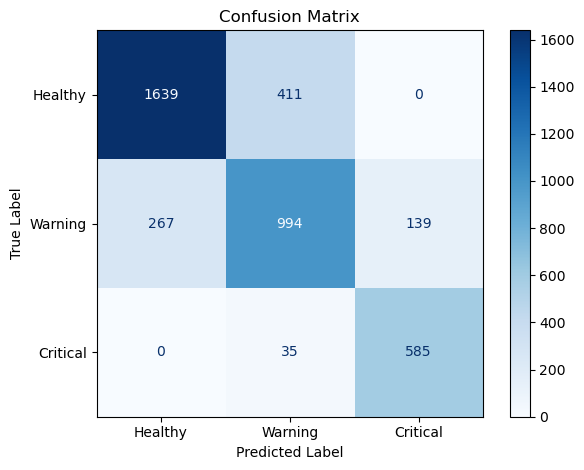

In [15]:
plot_cm(y_val, y_pred_lr)

### Random Forest

In [16]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

In [17]:
rf_results = evaluate(y_val, y_pred_rf, "Random Forest")
rf_results

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,Random Forest,0.82,0.81,0.81,0.9,0.85


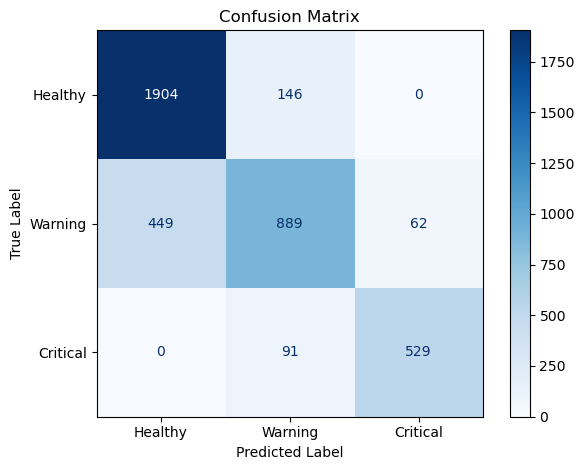

In [18]:
plot_cm(y_val, y_pred_rf)

### Gradient Boosting

Since Gradient Boosting does not support `class_weight='balanced'`, we use `compute_sample_weight` to assign balanced sample weights manually.

In [19]:

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb_model.predict(X_val)

In [20]:
gb_results = evaluate(y_val, y_pred_gb, "Gradient Boosting")
gb_results

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,Gradient Boosting,0.8,0.82,0.81,0.82,0.93


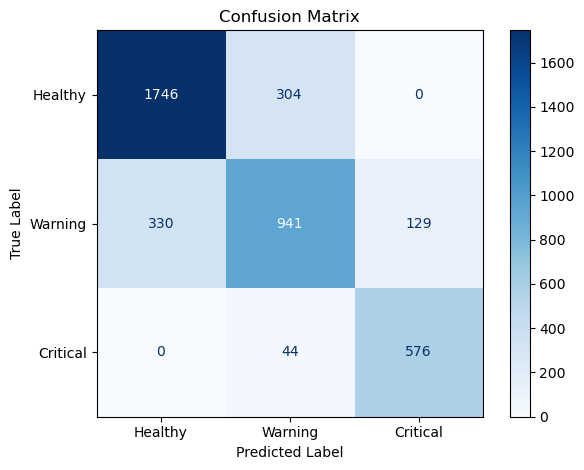

In [21]:
plot_cm(y_val, y_pred_gb)

### XGBoost

In [22]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss",
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_model.predict(X_val)

In [23]:
xgb_results = evaluate(y_val, y_pred_xgb, "XGBoost")
xgb_results

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,XGBoost,0.81,0.82,0.81,0.82,0.93


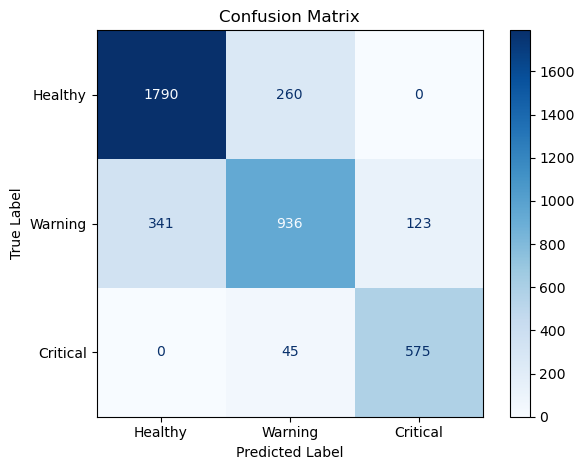

In [24]:
plot_cm(y_val, y_pred_xgb)

In [25]:
all_results = [lr_results, rf_results, gb_results, xgb_results]

final_results = pd.concat(all_results, ignore_index=True)

final_results.sort_values("Critical Recall", ascending= False).reset_index(drop=True)

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,logistic regression,0.79,0.82,0.80,0.81,0.94
1,Gradient Boosting,0.80,0.82,0.81,0.82,0.93
2,XGBoost,0.81,0.82,0.81,0.82,0.93
3,Random Forest,0.82,0.81,0.81,0.90,0.85


### Model Comparison with Class Weighting


Gradient Boosting achieves the highest **Balanced Accuracy (0.82)** and a **Macro F1-score of 0.81**, while Logistic Regression achieves the highest **Critical Recall (0.94)**. This indicates that Logistic Regression is particularly effective at identifying engines that are actually in the Critical state.

Gradient Boosting also performs well on the Critical class, achieving a **Critical Recall of 0.93** with a Critical Precision of 0.82.

XGBoost and Random Forest achieve the highest overall **Accuracy (0.82)**. XGBoost also provides a strong balance between Critical Precision (0.90) and Critical Recall (0.86).

Overall, the results suggest that there is no single model that dominates across all evaluation metrics. Logistic Regression and Gradient Boosting are particularly strong in detecting Critical engines, while XGBoost provides strong overall performance with a good balance between Critical Precision and Recall.

These results will be used as the basis for the next stage: **Hyperparameter Tuning and final model selection**.


## Hyperparameter Tuning

In [ ]:

critical_recall_scorer = make_scorer(recall_score, average=None, labels=[Critical])


In [27]:

group_kfold = GroupKFold(n_splits=3)

### Logistic Regression

In [65]:

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "newton-cg"],
    "max_iter": [100, 500, 1000],
    "class_weight": ['balanced']
}

lr_search = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=lr_param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=group_kfold,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train, y_train, groups=train_engine_ids)

c:\Users\hosse\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


RandomizedSearchCV(cv=GroupKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=LogisticRegression(class_weight='balanced',
                                                max_iter=1000,
                                                multi_class='multinomial',
                                                random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100],
                                        'class_weight': ['balanced'],
                                        'max_iter': [100, 500, 1000],
                                        'solver': ['lbfgs', 'newton-cg']},
                   random_state=42, scoring='f1_macro')

In [66]:
best_lr = lr_search.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_val)
lr_tuned_results = evaluate(y_val, y_pred_lr_tuned, "lr_tuned")
lr_tuned_results


,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,lr_tuned,0.79,0.82,0.8,0.81,0.94


### Gradient Boosting

In [67]:

gb_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=group_kfold,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train, groups=train_engine_ids, sample_weight=sample_weights)

RandomizedSearchCV(cv=GroupKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200]},
                   random_state=42, scoring='f1_macro')

In [68]:

best_gb = gb_search.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_val)
gb_tuned_results = evaluate(y_val, y_pred_gb_tuned, "gb_tuned")
gb_tuned_results

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,gb_tuned,0.8,0.82,0.81,0.82,0.93


### XGBoost

In [69]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=group_kfold,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train, groups=train_engine_ids, sample_weight=sample_weights)

RandomizedSearchCV(cv=GroupKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           g...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=200, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1_macro')

In [70]:

best_xgb = xgb_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_val)
xgb_tuned_results = evaluate(y_val, y_pred_xgb_tuned, "xgb_tuned")
xgb_tuned_results

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,xgb_tuned,0.81,0.82,0.81,0.85,0.91


### Random Forest

In [71]:
rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ['balanced']
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=group_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(
    X_train,
    y_train,
    groups=train_engine_ids,
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_estimators=200, n_jobs=-1,
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced'],
                                        'max_depth': [None, 5, 10, 15, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [72]:

best_rf = rf_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_val)
rf_tuned_results = evaluate(y_val, y_pred_rf_tuned, "rf_tuned")
rf_tuned_results

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,rf_tuned,0.82,0.81,0.82,0.9,0.87


In [73]:
all_results = [lr_results, rf_results, gb_results, xgb_results, gb_tuned_results, xgb_tuned_results, lr_tuned_results, rf_tuned_results]

final_results = pd.concat(all_results, ignore_index=True)

final_results.sort_values("Critical Recall", ascending= False).reset_index(drop=True)

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,logistic regression,0.79,0.82,0.80,0.81,0.94
1,lr_tuned,0.79,0.82,0.80,0.81,0.94
2,XGBoost,0.81,0.82,0.81,0.82,0.93
3,Gradient Boosting,0.80,0.82,0.81,0.82,0.93
4,gb_tuned,0.80,0.82,0.81,0.82,0.93
5,xgb_tuned,0.81,0.82,0.81,0.85,0.91
6,rf_tuned,0.82,0.81,0.82,0.90,0.87
7,Random Forest,0.82,0.81,0.81,0.90,0.85


## Detailed Evaluation 

we chose Logistic Regression, Gradient Boosting and GB Tuned for evaluation.

### GB Tuned

In [74]:

print(classification_report(
    y_val,
    y_pred_gb_tuned,
    target_names=["Healthy", "Warning", "Critical"]
))

              precision    recall  f1-score   support

     Healthy       0.84      0.86      0.85      2050
     Warning       0.74      0.67      0.70      1400
    Critical       0.82      0.93      0.87       620

    accuracy                           0.80      4070
   macro avg       0.80      0.82      0.81      4070
weighted avg       0.80      0.80      0.80      4070



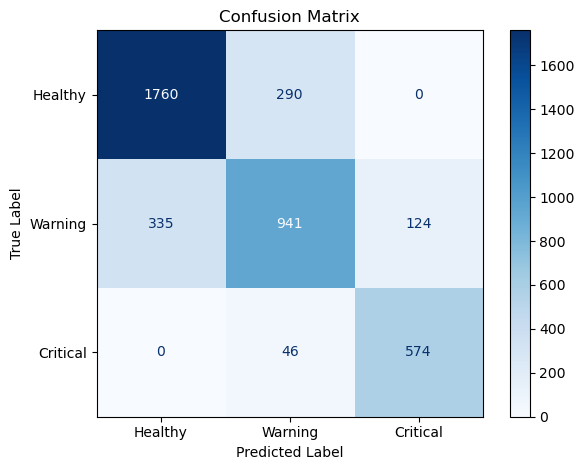

In [75]:
plot_cm(
    y_val,
    y_pred_gb_tuned,
)

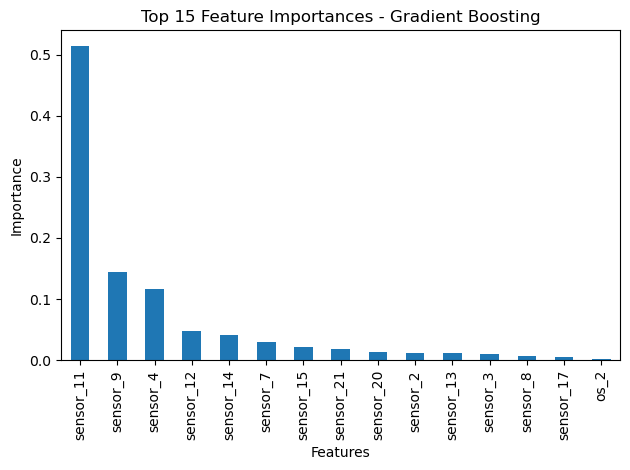

In [76]:
feature_importance = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15).plot(kind="bar")

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### Gradient Boosting

In [77]:

print(classification_report(
    y_val,
    y_pred_gb,
    target_names=["Healthy", "Warning", "Critical"]
))

              precision    recall  f1-score   support

     Healthy       0.84      0.85      0.85      2050
     Warning       0.73      0.67      0.70      1400
    Critical       0.82      0.93      0.87       620

    accuracy                           0.80      4070
   macro avg       0.80      0.82      0.81      4070
weighted avg       0.80      0.80      0.80      4070



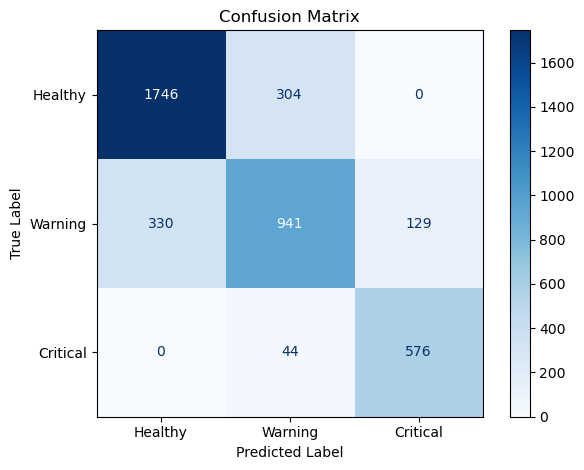

In [78]:
plot_cm(
    y_val,
    y_pred_gb,
)

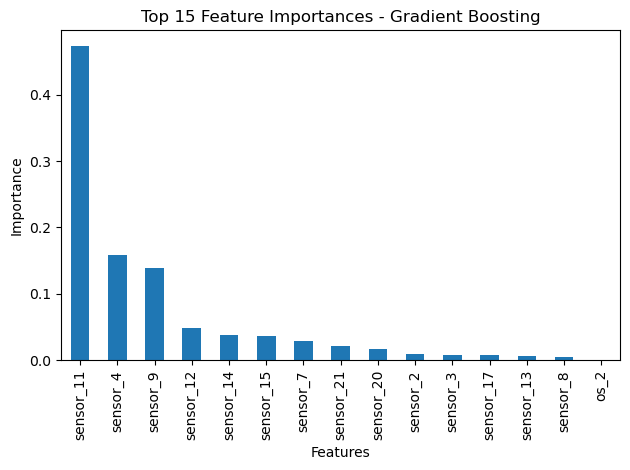

In [79]:
feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15).plot(kind="bar")

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### Logistic Regression

In [80]:
print(classification_report(
    y_val,
    y_pred_lr,
    target_names=["Healthy", "Warning", "Critical"]
))

              precision    recall  f1-score   support

     Healthy       0.86      0.80      0.83      2050
     Warning       0.69      0.71      0.70      1400
    Critical       0.81      0.94      0.87       620

    accuracy                           0.79      4070
   macro avg       0.79      0.82      0.80      4070
weighted avg       0.79      0.79      0.79      4070



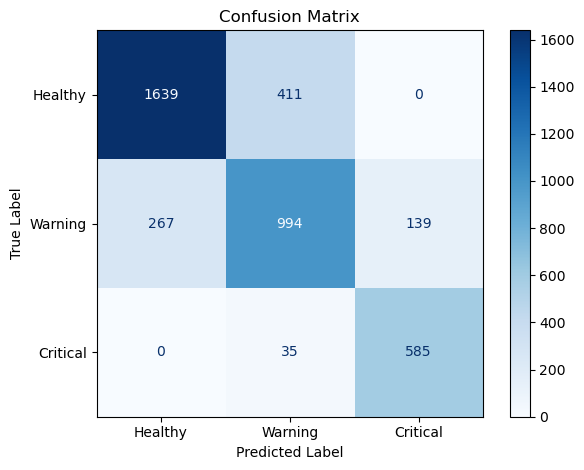

In [81]:
plot_cm(
    y_val,
    y_pred_lr,
)

## final model 

In [90]:
final_model = xgb_model

In [98]:
X_final_train = pd.concat(
    [X_train, X_val],
    axis=0
)

y_final_train = pd.concat(
    [y_train, y_val],
    axis=0
)
final_weights = compute_sample_weight(class_weight='balanced', y=y_final_train)
print(X_final_train.shape)
print(y_final_train.shape)

(20631, 16)
(20631,)


In [99]:
final_model.fit(X_final_train, y_final_train, sample_weight=final_weights )

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

## Final Evaluation

In [100]:
y_test_pred = final_model.predict(X_test)

In [101]:
final_score = evaluate(
    y_test,
    y_test_pred,
    "final model"
)

final_score

,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,final model,0.7,0.71,0.71,0.9,0.72


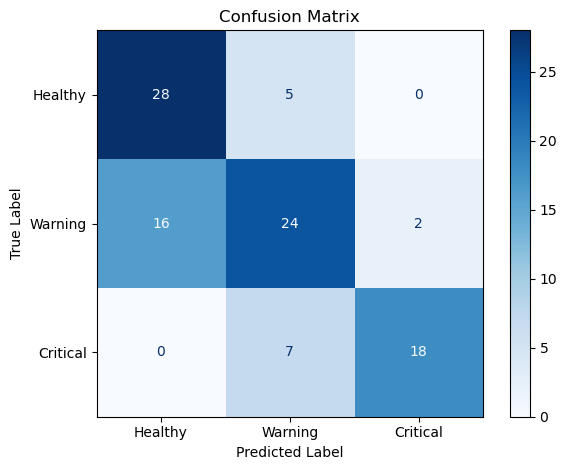

In [102]:
plot_cm(
    y_test,
    y_test_pred
)

In [103]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Healthy", "Warning", "Critical"]
    )
)

              precision    recall  f1-score   support

     Healthy       0.64      0.85      0.73        33
     Warning       0.67      0.57      0.62        42
    Critical       0.90      0.72      0.80        25

    accuracy                           0.70       100
   macro avg       0.73      0.71      0.71       100
weighted avg       0.71      0.70      0.70       100

